In [21]:
import mpld3
import numpy as np
from matplotlib import pyplot as plt
from pydrake.all import (
    AddDefaultVisualization,
    ConnectPlanarSceneGraphVisualizer,
    IrisFromCliqueCoverOptions,
    IrisInConfigurationSpaceFromCliqueCover,
    RandomGenerator,
    RigidTransform,
    RobotDiagramBuilder,
    SceneGraphCollisionChecker,
    StartMeshcat,
    VPolytope,
)
import pickle
from pydrake.solvers import MosekSolver
from pydrake.geometry.optimization import GraphOfConvexSetsOptions, HPolyhedron, Point
from pydrake.planning import GcsTrajectoryOptimization
from scipy.spatial import ConvexHull

from gcs.bezier import BezierGCS
from gcs.linear import LinearGCS

from utils import ConfigureParser
import time




In [22]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7000


In [23]:
sr2 = np.sqrt(2)

# obstacles
obstacles = [
    # 1. Vật cản hình Tam giác (Đa giác 3 cạnh)
    np.array([
        [0.5, 0.5],
        [1.5, 0.5],
        [1.0, 1.5]
    ]),

    # 2. Vật cản hình Chữ nhật (Đa giác 4 cạnh)
    np.array([
        [3.5, 0.5],
        [4.5, 0.5],
        [4.5, 1.5],
        [3.5, 1.5]
    ]),

    # 3. Vật cản hình CHỮ C (Đa giác lõm)
    # Được tạo bằng cách đi từ cạnh ngoài vào lòng chữ C
    np.array([
        [3.5, 4.0], [2.0, 4.0], # Cạnh trên ngoài
        [2.0, 2.0],             # Cạnh lưng ngoài
        [3.5, 2.0],             # Cạnh dưới ngoài
        [3.5, 2.5],             # Cạnh dưới trong
        [2.5, 2.5],             # Cạnh lưng trong
        [2.5, 3.5],             # Cạnh trên trong
        [3.5, 3.5]              # Đóng chữ C
    ]),

    # 4. Vật cản hình Ngũ giác (Đa giác 5 cạnh)
    np.array([
        [0.5, 3.0],
        [1.2, 2.5],
        [1.8, 3.0],
        [1.5, 4.0],
        [0.8, 4.0]
    ])
]

# obstacles = [
#         np.array([[2.6, 5.0], [3.6, 3.9], [4.9, 4.9], [4.9, 2.7], [2.6, 4.3], [2.6, 3.0], [4.4, 2.3], [2.7, 3.1], [2.9, 4.3], [4.9, 2.6], [4.9, 1.1], [3.9, 1.7], [4.9, 0.1], [2.7, 0.1], [4.7, 0.6], [3.7, 0.8], [4.7, 2.4], [2.9, 0.4], [1.1, 1.3], [2.7, 0.6], [3.3, 1.7], [0.3, 0.3], [5.0, 0.0], [5.0, 5.0]]),
#         np.array([[0.0, 5.0], [0.0, 0.0], [2.4, 0.0], [0.1, 0.1], [0.1, 1.3], [3.0, 1.3], [2.7, 4.7], [1.3, 4.0], [2.3, 3.9], [2.3, 2.3], [3.3, 2.6], [2.3, 2.0], [2.9, 1.4], [1.6, 2.0], [2.1, 1.1], [0.7, 1.7], [1.4, 2.9], [2.0, 2.3], [2.0, 3.7], [1.0, 3.7], [0.1, 1.4], [0.1, 3.3], [0.3, 1.6], [1.1, 2.7], [0.1, 4.9], [0.4, 3.6], [0.7, 4.9], [2.4, 5.0]]),
#     ]

# vertices of the safe regions
vertices = [
    np.array([[0.4, 0.0], [0.4, 5.0], [0.0, 5.0], [0.0, 0.0]]),
    np.array([[0.4, 2.4], [1.0, 2.4], [1.0, 2.6], [0.4, 2.6]]),
    np.array([[1.4, 2.2], [1.4, 4.6], [1.0, 4.6], [1.0, 2.2]]),
    np.array([[1.4, 2.2], [2.4, 2.6], [2.4, 2.8], [1.4, 2.8]]),
    np.array([[2.2, 2.8], [2.4, 2.8], [2.4, 4.6], [2.2, 4.6]]),
    np.array([[1.4, 2.2], [1.0, 2.2], [1.0, 0.0], [3.8, 0.0], [3.8, 0.2]]),
    np.array([[3.8, 4.6], [3.8, 5.0], [1.0, 5.0], [1.0, 4.6]]),
    np.array([[5.0, 0.0], [5.0, 1.2], [4.8, 1.2], [3.8, 0.2], [3.8, 0.0]]),
    np.array([[3.4, 2.6], [4.8, 1.2], [5.0, 1.2], [5.0, 2.6]]),
    np.array([[3.4, 2.6], [3.8, 2.6], [3.8, 4.6], [3.4, 4.6]]),
    np.array([[3.8, 2.8], [4.4, 2.8], [4.4, 3.0], [3.8, 3.0]]),
    np.array([[5.0, 2.8], [5.0, 5.0], [4.4, 5.0], [4.4, 2.8]]),
]

x_min = np.min(np.vstack(vertices), axis=0)
x_max = np.max(np.vstack(vertices), axis=0)

x_start = np.array([0.2, 0.2])
x_goal = np.array([4.8, 4.8])


def make_hpolytope(V):
    ch = ConvexHull(V)
    return HPolyhedron(ch.equations[:, :-1], -ch.equations[:, -1])


regions = [make_hpolytope(V) for V in vertices]


def environment_setup():
    plt.figure(figsize=(5, 5))
    plt.axis("square")

    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    plt.axis('off')
    tick_gap = 0.2

    def n_ticks(x_min, x_max):
        return round((x_max - x_min) / tick_gap) + 1

    x_ticks = np.linspace(x_min[0], x_max[0], n_ticks(x_min[0], x_max[0]))
    y_ticks = np.linspace(x_min[1], x_max[1], n_ticks(x_min[1], x_max[1]))
    plt.xticks(x_ticks)
    plt.yticks(y_ticks)

    label_gap = 0.5

    def keep_label(t):
        return np.isclose(t % label_gap, 0) or np.isclose(t % label_gap, label_gap)

    x_labels = [int(t) if keep_label(t) else "" for t in x_ticks]
    y_labels = [int(t) if keep_label(t) else "" for t in y_ticks]
    plt.gca().set_xticklabels(x_labels)
    plt.gca().set_yticklabels(y_labels)
    # plt.savefig("my_plot.png", bbox_inches='tight', pad_inches=0)
    # plt.grid()
    # plt.savefig("my_plot.png", bbox_inches='tight', pad_inches=0)
    # plt.show()


def plot_trajectory(traj):
    plt.figure(figsize=(6, 6))

    for O in obstacles:
        plt.fill(*O.T, fc="lightcoral", ec="k", zorder=4)

    plt.plot(*traj.value(traj.start_time()), "kx")
    plt.plot(*traj.value(traj.end_time()), "kx")
    times = np.linspace(traj.start_time(), traj.end_time(), 1000)
    waypoints = traj.vector_values(times)
    plt.plot(*waypoints, "b", zorder=5)

    plt.axis("square")
    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    plt.xticks(range(6))
    plt.yticks(range(6))
    plt.grid(1)


def plot_velocity(traj):
    vel = traj.MakeDerivative()

    plt.figure(figsize=(6, 4))

    for i in range(vel.get_number_of_segments()):
        v = vel.segment(i)
        times = np.linspace(v.start_time(), v.end_time(), 500)
        values = v.vector_values(times)
        plt.plot(times, values[0], color="tab:blue")
        plt.plot(times, values[1], color="tab:orange")

    plt.xlim([traj.start_time(), traj.end_time()])
    plt.xticks(np.arange(int(np.ceil(traj.end_time() / 2))) * 2)
    plt.yticks(np.linspace(qdot_min, qdot_max, 5))
    plt.xlabel("Time $t$")
    plt.ylabel("Velocity $\dot{q}$")
    plt.grid()


def print_gcs_result(result_dict):
    print("=== Relaxation Result ===")
    print(f"Cost: {result_dict['relaxation_cost']:.3f}")
    print(f"Solver time: {result_dict['relaxation_solver_time']:.4f}s")
    
    print()

    print("=== Rounded Result ===")
    print(f"Rounded cost: {result_dict['rounded_cost']:.3f}")
    print()
    final_cost = 0
    for i, e in enumerate(result_dict["best_path"], 1):
        phi = result_dict["best_result"].GetSolution(e.phi())
        cost = e.GetSolutionCost(result_dict["best_result"])
        final_cost = final_cost + cost
        print(f"Edge {i}: {e.u().name()} → {e.v().name()}, cost = {cost:3f}, phi = {phi:3f}")
    print (f"Sum cost rounded: {final_cost:3f}")
    
    print()
    print("=== Solver Details ===")
    best = result_dict["best_result"]
    print(f"Solver: {best.get_solver_id().name()}")
    print(f"Success: {best.is_success()}")
    print(f"Optimal cost: {best.get_optimal_cost():.3f}")

def get_detail_results(traj, result_dict):
    print(f"Start time: {traj.start_time()} - End time: {traj.end_time()}")
    time_cost = traj.end_time() - traj.start_time()
    path_cost = result_dict['rounded_cost']
    return time_cost, path_cost

<>:146: SyntaxWarning: invalid escape sequence '\d'
<>:146: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_43658/2643533357.py:146: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel("Velocity $\dot{q}$")


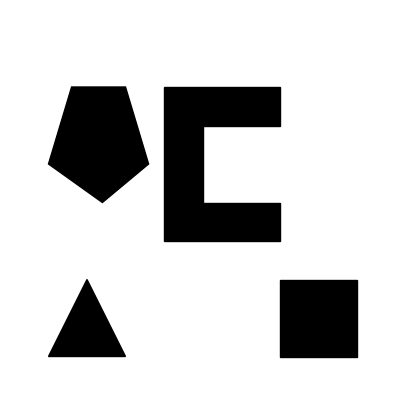

In [24]:
environment_setup()

for O in obstacles:
    plt.fill(*O.T, fc="black", ec="k", zorder=4)

# plt.plot(*x_start, "kx")
# plt.plot(*x_goal, "kx")

# plt.text(0.2, 0.35, "$q_0$", ha="center", va="bottom")
# plt.text(4.8, 4.65, "$q_T$", ha="center", va="top")
plt.savefig("environment.png", bbox_inches='tight', pad_inches=0)

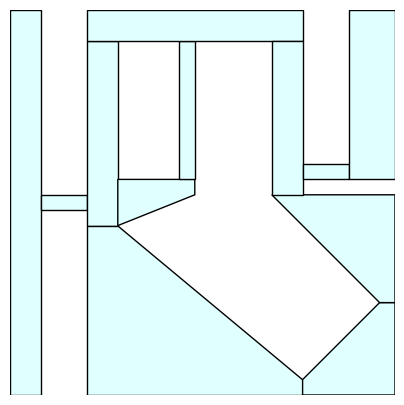

In [25]:
environment_setup()

for V in vertices:
    plt.fill(*V.T, fc="lightcyan", ec="k", zorder=4)

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.


result.is_success() = True
[0.0, 1e-06, 7.475153523717885, 8.075153523717885, 14.187919213654258, 19.723682862297295, 21.523682862297296, 28.056281634185673, 34.12936500397595, 34.72936500397595, 42.02951603053513, 42.029517030535125]


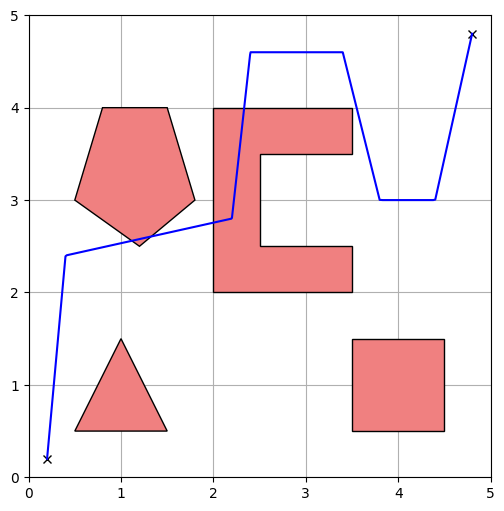

In [26]:
qdot_min = -1
qdot_max = 1


def solve_min_distance(order=1):
    trajopt = GcsTrajectoryOptimization(2)
    gcs_regions = trajopt.AddRegions(regions, order=order)
    source = trajopt.AddRegions([Point(x_start)], order=0)
    target = trajopt.AddRegions([Point(x_goal)], order=0)
    trajopt.AddEdges(source, gcs_regions)
    trajopt.AddEdges(gcs_regions, target)
    trajopt.AddPathLengthCost()
    trajopt.AddVelocityBounds([qdot_min] * 2, [qdot_max] * 2)
    options = GraphOfConvexSetsOptions()
    [traj, result] = trajopt.SolvePath(source, target, options)
    print(f"result.is_success() = {result.is_success()}")
    if result.is_success():
        print(traj.get_segment_times())
        plot_trajectory(traj)


solve_min_distance()

In [27]:
qdot_min = -1
qdot_max = 1


def solve_min_time(regions, order, continuity_order, hdot_min=1e-6, regularizer=None, velocity=None):
    gcs = BezierGCS(regions, order, continuity_order, hdot_min=hdot_min)

    gcs.addTimeCost(1)
    gcs.addVelocityLimits([qdot_min] * 2, [qdot_max] * 2)
    if regularizer is not None:
        gcs.addDerivativeRegularization(*regularizer, 2)
    gcs.addSourceTarget(x_start, x_goal, velocity=velocity)
    
    gcs.setSolver(MosekSolver())
    gcs.setPaperSolverOptions()
    
    [traj, result] = gcs.SolvePath(True)
    output_file = 'trajectory.pkl'
    with open(output_file, 'wb') as f:
        pickle.dump(traj, f)
    
    print(f"\nTrajectory saved to: {output_file}")
    return traj, result

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1541            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 411             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 295
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 21
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes   

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 3 unique paths, discarded 97 duplicate paths.
INFO:drake:Finished 3 rounding solutions with MOSEK.


13  1.3e-07  1.2e-07  2.3e-08  1.00e+00   9.879999607e+00   9.879999952e+00   1.8e-11  0.09  
14  2.9e-08  2.3e-08  4.4e-09  1.00e+00   9.879999925e+00   9.879999991e+00   3.4e-12  0.10  
15  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.10  
16  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.11  
Basis identification started.
Basis identification initialization started.
Basis identification initialization terminated. Time: 0.00
Primal basis identification phase started.
Primal basis identification phase terminated. Time: 0.00
Dual basis identification phase started.
Dual basis identification phase terminated. Time: 0.00
Initialization.                            Time: 0.00        
Primal.          Iterations: 16            Time: 0.00        
Dual.            Iterations: 116           Time: 0.00        
Optimization.    Iterations: 0             Time: 0.00        
Basis identification terminated. Time: 0.00
Op

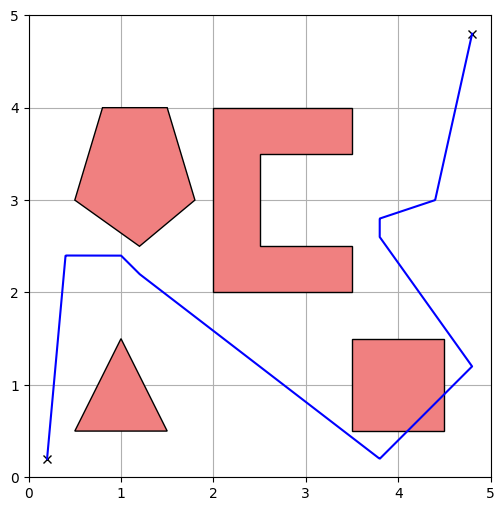

In [28]:
order = 1
continuity = 0
traj, results = solve_min_time(regions, order, continuity)

plot_trajectory(traj)

# plot_velocity(traj)


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 5558            
  Affine conic cons.     : 290 (1015 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 1571            
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 945
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 123
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes 

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


42  2.0e-06  1.2e-05  2.9e-08  1.01e+00   2.660490687e+01   2.660455610e+01   1.2e-08  1.56  
43  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.59  
44  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.63  
45  4.3e-07  1.4e-06  1.6e-09  1.00e+00   2.661744544e+01   2.661740594e+01   1.7e-09  1.66  
Optimizer terminated. Time: 1.66    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.6617445439e+01    nrm: 1e+03    Viol.  con: 8e-01    var: 0e+00    acc: 3e-02  
  Dual.    obj: -6.0565476304e+03   nrm: 2e+21    Viol.  con: 5e-08    var: 6e+03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 5558            
  Affine conic cons.     : 290 (1015 rows)
  Disjunctive cons.      : 0           

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 4 unique paths, discarded 96 duplicate paths.


40  8.6e-06  5.2e-05  2.1e-07  1.04e+00   2.655662450e+01   2.655511040e+01   2.8e-08  1.48  
41  3.0e-06  1.8e-05  5.0e-08  1.04e+00   2.659057489e+01   2.659005342e+01   1.4e-08  1.51  
42  2.0e-06  1.2e-05  2.9e-08  1.01e+00   2.660490687e+01   2.660455610e+01   1.2e-08  1.54  
43  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.57  
44  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.61  
45  4.3e-07  1.4e-06  1.6e-09  1.00e+00   2.661744544e+01   2.661740594e+01   1.7e-09  1.64  
Optimizer terminated. Time: 1.64    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.6617445439e+01    nrm: 1e+03    Viol.  con: 8e-01    var: 0e+00    acc: 3e-02  
  Dual.    obj: -6.0565476304e+03   nrm: 2e+21    Viol.  con: 5e-08    var: 6e+03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        


INFO:drake:Finished 4 rounding solutions with MOSEK.


6   8.1e+00  4.1e-03  6.1e-02  6.14e-01   5.364722057e+02   5.543781724e+02   8.1e-03  0.04  
4   5.6e+01  2.8e-02  4.7e-01  -8.41e-01  2.583764715e+02   2.784547837e+02   5.6e-02  0.04  
6   1.2e+01  5.9e-03  9.8e-02  2.74e-01   5.868870932e+02   6.085201018e+02   1.2e-02  0.04  
5   1.9e+01  9.4e-03  1.8e-01  -5.19e-01  5.720531217e+02   6.005343844e+02   1.9e-02  0.04  
7   4.0e+00  2.0e-03  1.5e-02  1.02e+00   3.561812621e+02   3.601963729e+02   4.0e-03  0.04  
5   1.8e+01  8.9e-03  1.8e-01  -5.21e-01  5.627313636e+02   5.939497385e+02   1.8e-02  0.04  
7   6.5e+00  3.3e-03  3.1e-02  7.37e-01   4.493284987e+02   4.560810986e+02   6.5e-03  0.04  
8   1.2e+00  6.1e-04  1.7e-03  1.57e+00   1.021637274e+02   1.027469411e+02   1.2e-03  0.04  
6   1.4e+01  6.9e-03  1.1e-01  2.32e-01   5.777228374e+02   5.978417718e+02   1.4e-02  0.04  
6   1.3e+01  6.5e-03  1.1e-01  2.24e-01   5.577142308e+02   5.794351107e+02   1.3e-02  0.05  
9   3.8e-01  1.9e-04  3.0e-04  1.23e+00   4.187977596e+01   

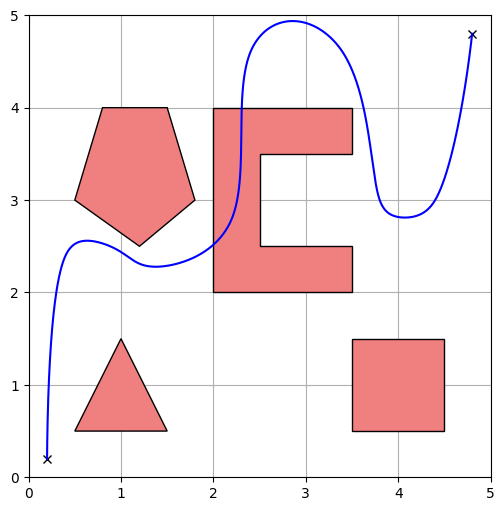

In [29]:
order = 6
continuity = 2
velocity = np.zeros((2, 2))
regularizer = [1e-1, 1e-1]

solve_time_manual = time.time()
traj_manual, results_manual = solve_min_time(regions, order, continuity, velocity=velocity, regularizer=regularizer)
solve_time_manual = time.time() - solve_time_manual
time_cost_manual, path_cost_manual = get_detail_results(traj_manual, results_manual)
print_gcs_result(results_manual)

plot_trajectory(traj_manual)

print(traj_manual)

# plot_velocity(traj)

## Approximate Convex Decomposition of Polygons

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ACD2D wrapper initialized with executable: /home/dang-khoa/code/motion-planning/gcs-science-robotics/acd2d/build/acd2d
Input file saved to: acd2d_input_1769433924.poly
Decomposed into 14 polygons with 17 cuts.

Polygon 1:
[[0.5      3.      ]
 [0.       2.82899 ]
 [0.       0.      ]
 [0.5      0.5     ]
 [0.999984 1.49997 ]
 [1.19997  2.50002 ]]

Polygon 2:
[[0.      4.15996]
 [0.      2.82899]
 [0.5     3.     ]
 [0.79999 3.99997]]

Polygon 3:
[[3.5   3.5  ]
 [3.875 3.125]
 [5.    5.   ]
 [3.5   4.   ]]

Polygon 4:
[[3.5   2.5  ]
 [3.875 3.125]
 [3.5   3.5  ]
 [2.5   3.5  ]
 [2.5   2.5  ]]

Polygon 5:
[[4.5     1.49996]
 [5.      5.     ]
 [3.5     2.5    ]
 [3.5     2.00004]]

Polygon 6:
[[5.       0.44448 ]
 [5.       5.      ]
 [4.5      1.49996 ]
 [4.5      0.500035]]

Polygon 7:
[[3.5      0.5     ]
 [0.       0.      ]
 [5.       0.      ]
 [5.       0.444409]
 [4.49996  0.5     ]]

Polygon 

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Optimizer terminated. Time: 3.72    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 8.9765146433e+00    nrm: 1e+03    Viol.  con: 1e-01    var: 0e+00    acc: 3e-03  
  Dual.    obj: 8.9782249489e+00    nrm: 5e+12    Viol.  con: 1e-07    var: 2e-03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 8739            
  Affine conic cons.     : 430 (1505 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 2351            
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 1070
Eliminator terminated.
El

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 10 unique paths, discarded 10 duplicate paths.


59  4.4e-07  8.5e-07  2.0e-09  9.96e-01   8.976514643e+00   8.976619485e+00   4.0e-10  3.65  
Optimizer terminated. Time: 3.72    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 8.9765146433e+00    nrm: 1e+03    Viol.  con: 1e-01    var: 0e+00    acc: 3e-03  
  Dual.    obj: 8.9782249489e+00    nrm: 5e+12    Viol.  con: 1e-07    var: 2e-03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : QO (quadratic optimization problem)
  Constraints            : 873             
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 214             
  Matrix variables       : 0               
  Integer variables      : 0               
Problem
  Name                   :                 
  Objective sense        : minimize        
  T

INFO:drake:Finished 10 rounding solutions with MOSEK.


43  4.8e-11  1.8e-12  1.1e-14  1.42e-02   2.465217670e+01   2.466982532e+01   8.4e-14  0.32  
47  1.0e-10  8.9e-10  3.2e-14  6.01e-01   4.537367769e+01   4.540810554e+01   1.1e-13  0.33  
44  4.8e-11  1.8e-12  1.1e-14  -9.43e-03  2.465780522e+01   2.467545420e+01   8.4e-14  0.33  
48  1.0e-10  8.9e-10  3.1e-14  6.00e-01   4.537390800e+01   4.540833530e+01   1.1e-13  0.34  
45  4.8e-11  1.8e-12  1.1e-14  1.63e-02   2.466097355e+01   2.467862268e+01   8.4e-14  0.34  
49  1.0e-10  8.9e-10  2.8e-14  6.02e-01   4.537391514e+01   4.540834245e+01   1.1e-13  0.34  
46  4.8e-11  1.8e-12  1.1e-14  -3.57e-02  2.466462100e+01   2.468227082e+01   8.4e-14  0.34  
50  1.0e-10  8.9e-10  2.8e-14  6.02e-01   4.537391514e+01   4.540834245e+01   1.1e-13  0.35  
47  4.8e-11  1.8e-12  1.1e-14  1.64e-02   2.466481909e+01   2.468246892e+01   8.4e-14  0.35  
Optimizer terminated. Time: 0.36    


Interior-point solution summary
  Problem status  : UNKNOWN
  Solution status : UNKNOWN
  Primal.  obj: 4.352874443

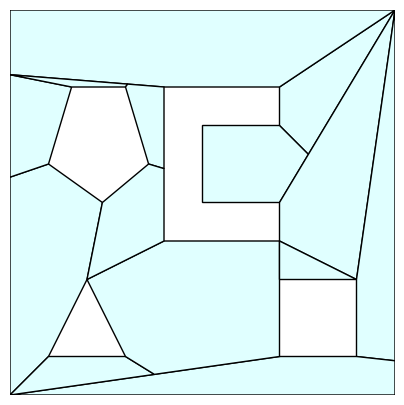

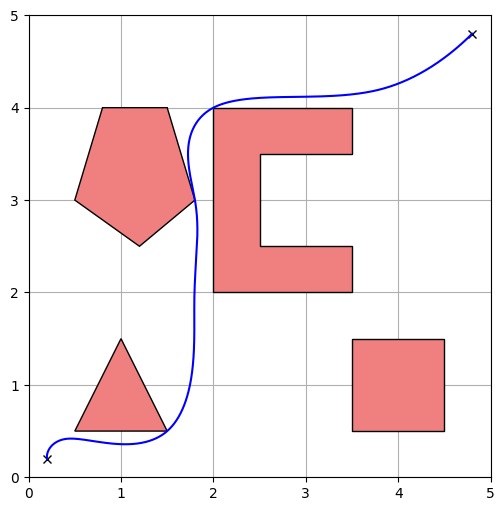

In [30]:
%load_ext autoreload
%autoreload 2

from acd2d.acd2d import ACD2D

# Setup
acd = ACD2D()
acd.set_parameters(tau=0.0)

x_start = np.array([0.2, 0.2])
x_goal = np.array([4.8, 4.8])
convex_relaxation = True

# Định nghĩa không gian làm việc 5x5
workspace = np.array([[0, 0], [5, 0], [5, 5], [0, 5]])

# Danh sách các chướng ngại vật (Obstacles)
obstacles = [
    # 1. Vật cản hình Tam giác (Đa giác 3 cạnh)
    np.array([
        [0.5, 0.5],
        [1.5, 0.5],
        [1.0, 1.5]
    ]),

    # 2. Vật cản hình Chữ nhật (Đa giác 4 cạnh)
    np.array([
        [3.5, 0.5],
        [4.5, 0.5],
        [4.5, 1.5],
        [3.5, 1.5]
    ]),

    # 3. Vật cản hình CHỮ C (Đa giác lõm)
    # Được tạo bằng cách đi từ cạnh ngoài vào lòng chữ C
    np.array([
        [3.5, 4.0], [2.0, 4.0], # Cạnh trên ngoài
        [2.0, 2.0],             # Cạnh lưng ngoài
        [3.5, 2.0],             # Cạnh dưới ngoài
        [3.5, 2.5],             # Cạnh dưới trong
        [2.5, 2.5],             # Cạnh lưng trong
        [2.5, 3.5],             # Cạnh trên trong
        [3.5, 3.5]              # Đóng chữ C
    ]),

    # 4. Vật cản hình Ngũ giác (Đa giác 5 cạnh)
    np.array([
        [0.5, 3.0],
        [1.2, 2.5],
        [1.8, 3.0],
        [1.5, 4.0],
        [0.8, 4.0]
    ])
]

order = 6
continuity = 2
velocity = np.zeros((2, 2))
regularizer = [1e-1, 1e-1]

acd2d_start = time.time()
regions_acd2d, results_CD = acd.decompose_to_hpolyhedron(workspace, holes=obstacles)
acd2d_time = time.time() - acd2d_start

solve_time_acd2d = time.time()
traj_acd2d, results_acd2d = solve_min_time(regions_acd2d, order, continuity, velocity=velocity, regularizer=regularizer)
solve_time_acd2d = time.time() - solve_time_acd2d
time_cost_acd2d, path_cost_acd2d = get_detail_results(traj_acd2d, results_acd2d)
print_gcs_result(results_acd2d)

# visualize convex regions
environment_setup()

for V in results_CD['polygons']:
    plt.fill(*V.T, fc="lightcyan", ec="k", zorder=4)


plot_trajectory(traj_acd2d)


## VCC

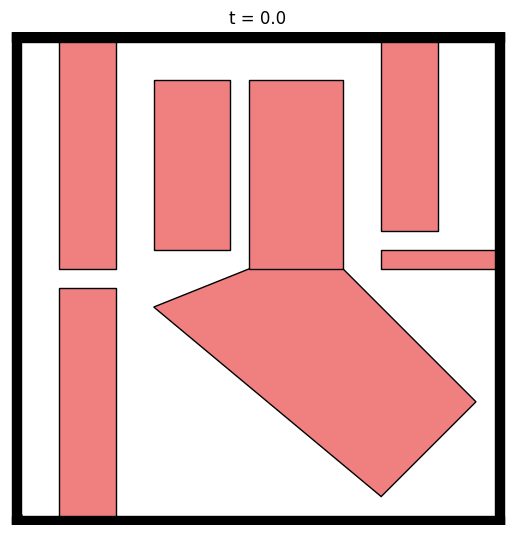

INFO:drake:Allocating contexts to support implicit context parallelism 16
INFO:drake:Current Fraction of Domain Covered = 0
INFO:drake:IrisFromCliqueCover Iteration 1/100


=== BẮT ĐẦU TẠO VÙNG AN TOÀN VỚI CLIQUE COVER ===


INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisFromCliqueCover Iteration 2/100
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp iteration 0
INFO:drake:IrisNp: Terminating because the iteration limit 1 has been reached.
INFO:drake:IrisNp: Terminating because t

Số vùng tìm được: 33


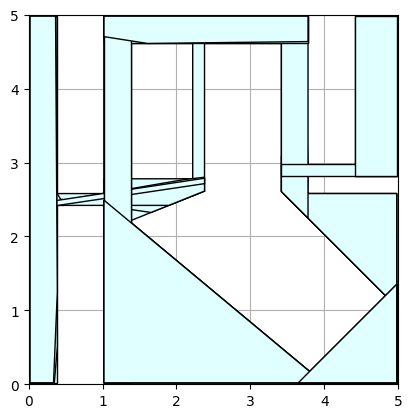

In [31]:
def BuildEnvironment():
    builder = RobotDiagramBuilder(time_step=0)
    parser = builder.parser()
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://manipulation/simple_2d_cspace.xml")
    builder.plant().Finalize()

    visualizer = ConnectPlanarSceneGraphVisualizer(
        builder.builder(),
        builder.scene_graph(),
        xlim=[-0.1, 5.1],
        ylim=[-0.1, 5.1],
        T_VW=np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1]]),
    )

    AddDefaultVisualization(builder.builder(), meshcat)

    return builder.Build()




meshcat.SetCameraTarget([0, 0, 0])
meshcat.Set2dRenderMode(
    X_WC=RigidTransform([0, 0, 5]), xmin=0, xmax=5, ymin=0, ymax=5
)
diagram = BuildEnvironment()
context = diagram.CreateDefaultContext()
diagram.ForcedPublish(context)

generator = RandomGenerator(1234)
checker = SceneGraphCollisionChecker(
    model=diagram,
    robot_model_instances=[diagram.plant().GetModelInstanceByName("robot")],
    edge_step_size=0.01,
)
options = IrisFromCliqueCoverOptions()
options.num_points_per_visibility_round = 200
options.coverage_termination_threshold = 0.96

# Đo thời gian tạo coverage
print("=== BẮT ĐẦU TẠO VÙNG AN TOÀN VỚI CLIQUE COVER ===")
coverage_start = time.time()
clique_regions = IrisInConfigurationSpaceFromCliqueCover(checker, options, generator, [])
coverage_time = time.time() - coverage_start
print(f"Số vùng tìm được: {len(clique_regions)}")

# Vẽ các vùng
diagram.GetSubsystemByName("planar_scenegraph_visualizer")
for region in clique_regions:
    V = VPolytope(region)
    hull = ConvexHull(V.vertices().T)
    plt.fill(
        V.vertices()[0, hull.vertices],
        V.vertices()[1, hull.vertices],
        fc="lightcyan",
        ec="k",
        zorder=4,
    )
plt.axis("square")
plt.xlim([x_min[0], x_max[0]])
plt.ylim([x_min[1], x_max[1]])
plt.xticks(range(6))
plt.yticks(range(6))
plt.grid(1)

plt.show()




=== GIẢI TRAJECTORY VỚI CLIQUE COVER ===
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 83214           
  Affine conic cons.     : 3180 (11130 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 17206           
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 576
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 6
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.02            
Lin. dep.  - primal atte

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Optimizer terminated. Time: 136.92  


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 8.1157701437e+00    nrm: 1e+03    Viol.  con: 5e-04    var: 0e+00    acc: 4e-04  
  Dual.    obj: 8.1157632783e+00    nrm: 3e+01    Viol.  con: 5e-09    var: 2e-07    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 83214           
  Affine conic cons.     : 3180 (11130 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 17206           
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 576
Eliminator terminated.
E

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 10 unique paths, discarded 0 duplicate paths.


Optimizer terminated. Time: 140.45  


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 8.1157701437e+00    nrm: 1e+03    Viol.  con: 5e-04    var: 0e+00    acc: 4e-04  
  Dual.    obj: 8.1157632783e+00    nrm: 3e+01    Viol.  con: 5e-09    var: 2e-07    acc: 0e+00  
Problem
Problem
  Name                   :                 
  Name                   :                 
  Objective sense        : minimize        
  Type                   : QO (quadratic optimization problem)
  Constraints            : 1016            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 193             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
  Objective sense        : minimize        
  Type                   : QO (quadratic optimization problem)
  Constraints 

INFO:drake:Finished 10 rounding solutions with MOSEK.


29  2.0e-07  9.9e-11  1.4e-13  1.00e+00   5.249275398e+01   5.249275413e+01   2.0e-10  0.73  
Optimizer terminated. Time: 0.73    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 5.2492669716e+01    nrm: 2e+01    Viol.  con: 3e-04    var: 0e+00  
  Dual.    obj: 5.2492699992e+01    nrm: 8e+01    Viol.  con: 3e-08    var: 1e-02  

Trajectory saved to: trajectory.pkl
Start time: 0.0 - End time: 12.95528330172685
=== Relaxation Result ===
Cost: 8.116
Solver time: 136.9179s

=== Rounded Result ===
Rounded cost: 28.210

Edge 1: source → v29, cost = 0.000000, phi = 1.000000
Edge 2: v29 → v16, cost = 14.033415, phi = 1.000000
Edge 3: v16 → v22, cost = 2.107380, phi = 1.000000
Edge 4: v22 → v28, cost = 0.667215, phi = 1.000000
Edge 5: v28 → v1, cost = 1.259849, phi = 1.000000
Edge 6: v1 → v30, cost = 1.757601, phi = 1.000000
Edge 7: v30 → v19, cost = 1.687158, phi = 1.000000
Edge 8: v19 → v4, cost = 0.471397, phi = 1.00

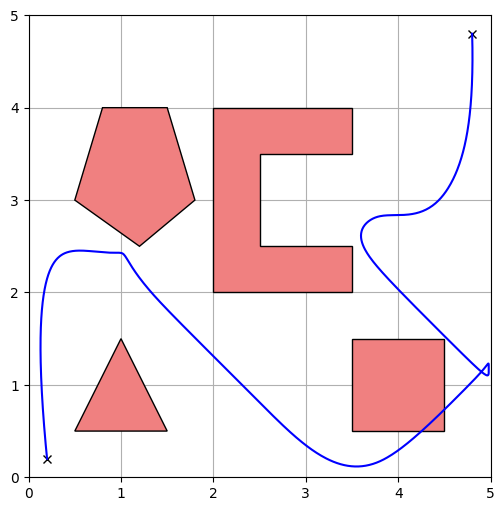

In [32]:
# Giải trajectory với Clique Cover regions
order = 6
continuity = 2
velocity = np.zeros((2, 2))
regularizer = [1e-1, 1e-1]

print("\n=== GIẢI TRAJECTORY VỚI CLIQUE COVER ===")
solve_start = time.time()
traj_clique, results_clique = solve_min_time(clique_regions, order, continuity, velocity=velocity, regularizer=regularizer)
solve_time_clique = time.time() - solve_start

time_cost_clique, path_cost_clique = get_detail_results(traj_clique, results_clique)
print_gcs_result(results_clique)

plot_trajectory(traj_clique)

## So sanh ket qua

In [33]:
print(f"Thời gian tạo coverage (VCC): {coverage_time:.4f}s")
# Bảng so sánh
print("\n" + "="*70)
print("                    BẢNG SO SÁNH KẾT QUẢ")
print("="*70)
print(f"{'Phương pháp':<25} {'Time Decomposition':<20} {'Số vùng':<12} {'T.gian giải (s)':<18} {'Time (s)':<15} {'Path cost (uint)':<15}")
print("-"*70)
print(f"{'Clique Cover':<25} {coverage_time:<20} {len(clique_regions):<12} {solve_time_clique:<18.4f} {time_cost_clique:<15.4f} {path_cost_clique:<15.4f}")
print(f"{'ACD2D':<25} {acd2d_time:<20.4f} {len(regions_acd2d):<12} {solve_time_acd2d:<18.4f} {time_cost_acd2d:<15.4f} {path_cost_acd2d:<15.4f}")
print(f"{'Phân hoạch thủ công':<25} {'':<20} {len(regions):<12} {solve_time_manual:<18.4f} {time_cost_manual:<15.4f} {path_cost_manual:<15.4f}")
print("-"*70)

# So sánh tổng thời gian
total_time_clique = coverage_time + solve_time_clique
total_time_manual = solve_time_manual  # không có thời gian tạo coverage
total_time_acd2d = acd2d_time + solve_time_acd2d

print(f"{'Tổng thời gian':<25} {'(bao gồm tạo coverage)'}")
print(f"{'Clique Cover':<25} {'':<12} {total_time_clique:<18.4f}")
print(f"{'Phân hoạch thủ công':<25} {'':<12} {total_time_manual:<18.4f}")
print(f"{'ACD2D':<25} {'':<12} {total_time_acd2d:<18.4f}")
print("="*70)

Thời gian tạo coverage (VCC): 5.1149s

                    BẢNG SO SÁNH KẾT QUẢ
Phương pháp               Time Decomposition   Số vùng      T.gian giải (s)    Time (s)        Path cost (uint)
----------------------------------------------------------------------
Clique Cover              5.11494779586792     33           282.2135           12.9553         28.2100        
ACD2D                     0.0111               14           8.4192             8.1234          11.1761        
Phân hoạch thủ công                            12           3.8748             13.3565         27.8805        
----------------------------------------------------------------------
Tổng thời gian            (bao gồm tạo coverage)
Clique Cover                           287.3284          
Phân hoạch thủ công                    3.8748            
ACD2D                                  8.4303            
